In [1]:
import os
import sys
import numpy as np
import h5py

sys.path.append('/data/visitors/nanomax/common/sw/ptypy-0.8/')
from ptypy.utils import rmphaseramp
from skimage.restoration import unwrap_phase

from skimage.registration import phase_cross_correlation
from scipy.ndimage import zoom, rotate, fourier_shift
import fsc as fsc

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib widget

WARNING ptypy - Message Passaging for Python (mpi4py) not found.
    CPU-parallelization disabled.
    Install python-mpi4py via the package repositories or with `pip install --user mpi4py`


### defining some useful functions

In [2]:
def shift_image(image, shift):
    offset_image = fourier_shift(np.fft.fftn(image), shift)
    offset_image = np.fft.ifftn(offset_image)
    return offset_image

In [3]:
def load_reconstructed_object(scan, 
                              sample, 
                              base, 
                              d='ptycho_ptypy_crop-1500_bin-1_Pmodes-2_dist-7.180',
                              crop = 1500):
    
    # load raw reconstructions
    fpath_in = f'{base}/process/{sample}/scan_{scan:0>6}/{d}/rec/rec_scan_{scan:0>6}_ML_cupy_3000.ptyr'
    with h5py.File(fpath_in, 'r') as f:
        data = np.array(f['content/obj/Sscan00G00/data'][0])
        psize = np.array(f['content/obj/Sscan00G00/_psize'][0])
        print(np.shape(data))

    # crop away the non-overlappingly scanned regions of the object
    d = crop//2
    data = data[d:-d,d:-d]
    return rmphaseramp(data), psize

### which reconstructions to load

In [4]:
base = '/data/staff/nanomax/commissioning_2025-2/20250821_img_startup/'
sample = '0001_setup'

scan1, scan2 = 74, 75  # EH1 at 11 keV

crop = 1500
d    = f'ptycho_ptypy_crop-{crop}_bin-1_Pmodes-2_dist-7.180'

### load the raw reconstructions

In [5]:
O1, psize = load_reconstructed_object(scan1, sample, base, d, crop)
O2, psize = load_reconstructed_object(scan2, sample, base, d, crop)
print(np.shape(O1))
print(np.shape(O2))

(2876, 2886)
(2877, 2885)
(1376, 1386)
(1377, 1385)


make both reconstructions the same size

In [6]:
O2 = O2[:np.shape(O1)[0],:np.shape(O1)[1]]
O1 = O1[:np.shape(O2)[0],:np.shape(O2)[1]]
O2 = O2[:np.shape(O1)[0],:np.shape(O1)[1]]

unwrap phase and remove offsets for plotting

In [7]:
O1_ph = unwrap_phase(np.angle(O1))
O2_ph = unwrap_phase(np.angle(O2))
O1_ph = O1_ph - np.max(O1_ph)
O2_ph = O2_ph - np.max(O2_ph)

show the two phase images and their unaligned difference

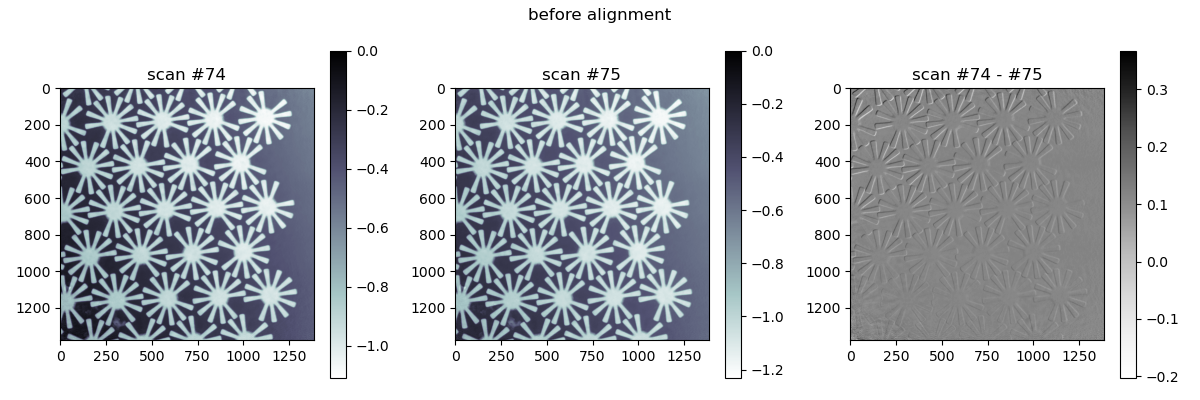

In [8]:
plt.figure(figsize=(12,4))
plt.suptitle('before alignment')

plt.subplot(1,3,1)
plt.title(f'scan #{scan1}')
plt.imshow(O1_ph, cmap='bone_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title(f'scan #{scan2}')
plt.imshow(O2_ph, cmap='bone_r')
plt.colorbar()

plt.subplot(1,3,3)
plt.title(f'scan #{scan1} - #{scan2}')
plt.imshow(O1_ph - O2_ph, cmap='Greys')#, vmin=-0.1, vmax=0.1)
plt.colorbar()

plt.tight_layout()
plt.show()

### align the two phase images
This is the "tricky" bit.

using the two complex valued images to find the shift vector

In [9]:
shift, error, diffphase = phase_cross_correlation(O1, O2, upsample_factor=100)
print(shift)

[0.12 0.33]


shift image #2 to match image #1

In [10]:
O1 = O1
O2 = shift_image(O2, shift)

crop away the shifted bit

In [11]:
vshift_px = int(shift[0])
hshift_px = int(shift[1])

if vshift_px>0:
    O1 = O1[vshift_px:, :]
    O2 = O2[vshift_px:, :]
elif vshift_px<0:
    O1 = O1[:vshift_px, :]
    O2 = O2[:vshift_px, :]

if hshift_px>0:
    O1 = O1[:, hshift_px:]
    O2 = O2[:, hshift_px:]
elif hshift_px<0:
    O1 = O1[:, :hshift_px]
    O2 = O2[:, :hshift_px]

calculate the shift vector again to see that they images are now aligned

In [12]:
shift, error, diffphase = phase_cross_correlation(O1, O2, upsample_factor=100)
print(shift)

[0. 0.]


show the two phase images and their difference after alignment

In [13]:
O1_ph = unwrap_phase(np.angle(O1))
O2_ph = unwrap_phase(np.angle(O2))
O1_ph = O1_ph - np.max(O1_ph)
O2_ph = O2_ph - np.max(O2_ph)

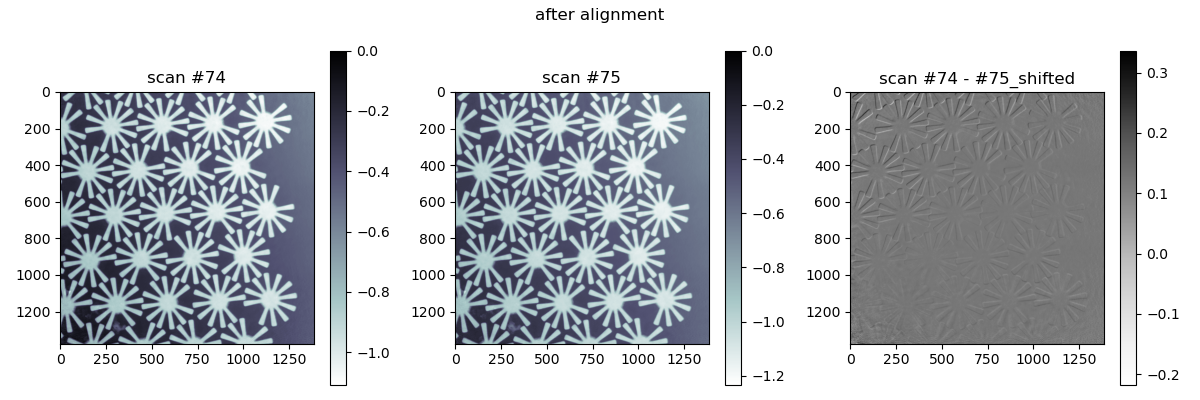

In [14]:
plt.figure(figsize=(12,4))
plt.suptitle('after alignment')

plt.subplot(1,3,1)
plt.title(f'scan #{scan1}')
plt.imshow(O1_ph, cmap='bone_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title(f'scan #{scan2}')
plt.imshow(O2_ph, cmap='bone_r')
plt.colorbar()

plt.subplot(1,3,3)
plt.title(f'scan #{scan1} - #{scan2}_shifted')
plt.imshow(O1_ph - O2_ph, cmap='Greys')
plt.colorbar()

plt.tight_layout()
plt.show()

### apply a window to both images

In [15]:
im1_w = fsc.apply_window2D(O1, type='hanning')
im2_w = fsc.apply_window2D(O2, type='hanning')

### calculate the FRC of the two aligned and windowed images

In [16]:
px_size_nm = psize * 1.e9
cropping = np.shape(im1_w)

FSC, nr, x  = fsc.fourier_ring_correlation(im1_w, im2_w, binning=4)
SSNR        = fsc.spectral_snr(FSC)
x_nm        = fsc.x_to_nm(x, px_size_nm)

In [17]:
y_half_bit  = fsc.frc_half_bit_curve_freq(x, cropping)      # frc_half_bit_curve(nr)
y_one_bit   = fsc.frc_one_bit_curve_freq(x, cropping)       # frc_one_bit_curve(nr)
x_half_bit  = x[fsc.find_x_cut(FSC, y_half_bit)]
x_one_bit   = x[fsc.find_x_cut(FSC, y_one_bit)]

if the found intersection point is giving beyond pixel resolution... force it to "pixel resolution"

In [18]:
if x_half_bit > 1: x_half_bit = 1
if x_one_bit > 1: x_one_bit = 1

In [19]:
nm_half_bit = fsc.x_to_nm(px_size_nm, x_half_bit)
nm_one_bit  = fsc.x_to_nm(px_size_nm, x_one_bit)
area = fsc.integrate_curve(x, FSC, 0.0, 1.0)

### plot the spatial signal to noise ratio

In [20]:
print('   finished calculation')
print('#'*80) 
print('    resolution: '+ str(nm_one_bit)[:5] +     ' nm (one bit criteria)')
print('    resolution: '+ str(nm_half_bit)[:5] +    ' nm (half bit criteria)')
print('     int. area: '+ str(area))
print('#'*80) 

   finished calculation
################################################################################
    resolution: 9.579 nm (one bit criteria)
    resolution: 8.770 nm (half bit criteria)
     int. area: 0.6664624194114186
################################################################################


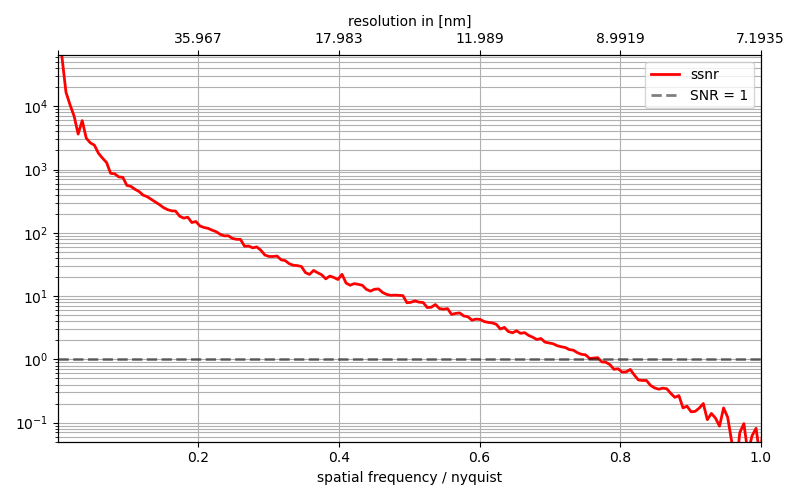

In [21]:
########################################################################
#   plot the spectral signal to noise ratio and the reference
########################################################################
fig1    = plt.figure(figsize=(8, 5), facecolor='white')
ax1     = plt.subplot(1,1,1)

line0,  = ax1.plot(x[1:-1], SSNR,          lw=2,           c='r',              label='ssnr')
line4   = ax1.axhline(y=1,  lw=2, ls='--',  c='k', alpha=0.5,   label='SNR = 1')

plt.xlim([0.0001, 1.])
plt.ylim([0.05,1.05*SSNR.max()])
plt.semilogy()
plt.xlabel('spatial frequency / nyquist')
plt.grid(which='both')
plt.legend(loc=1)

########################################################################
#   add a second axis with the resolution
########################################################################
ax2         = ax1.twiny()

xticks      = ax1.get_xticks()
xtick_str   = ['']
for xtick in xticks[1:]: 
    xtick_str.append(str(fsc.x_to_nm(px_size_nm, xtick))[:6])
plt.xticks(xticks, xtick_str)
plt.xlabel('resolution in [nm]')
plt.tight_layout()
#plt.savefig(f'scans_{scan1:0>6}_{scan2:0>6}_SSNR.png')

### plot the fourier ring correlation

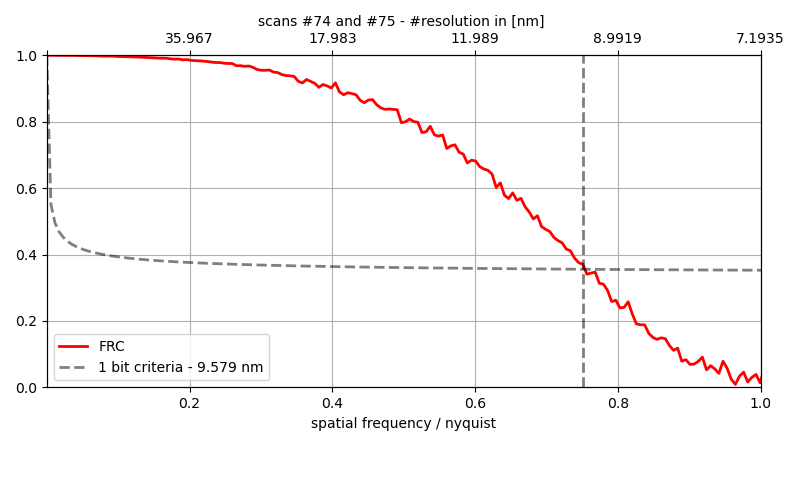

In [22]:
########################################################################
#   plot the fsc, the reference curves and their intersections
########################################################################
fig2     = plt.figure(figsize=(8, 5), facecolor='white')
ax2     = plt.subplot2grid((5, 1), (0, 0), rowspan=4)

line0,  = ax2.plot(x, FSC,          lw=2,           c='r',              label='FRC')
#line1,  = ax2.plot(x, y_half_bit,   lw=2, ls='-',   c='k', alpha=0.5,   label='_nolegend_')
line2,  = ax2.plot(x, y_one_bit,    lw=2, ls='--',  c='k', alpha=0.5,   label='_nolegend_')
#line3   = ax2.axvline(x=x_half_bit, lw=2, ls='-',   c='k', alpha=0.5,   label='.5 bit criteria - '+str(nm_half_bit)[:5]+' nm')
line4   = ax2.axvline(x=x_one_bit,  lw=2, ls='--',  c='k', alpha=0.5,   label='1 bit criteria - '+str(nm_one_bit)[:5]+' nm')

plt.xlim([0.0001, 1.])
plt.ylim([0,1.])
plt.xlabel('spatial frequency / nyquist')
plt.grid(which='both')
plt.legend(loc=3)

########################################################################
#   add a second axis with the resolution
########################################################################
ax2         = ax2.twiny()

xticks      = ax2.get_xticks()
xtick_str   = ['']
for xtick in xticks[1:]: 
    xtick_str.append(str(fsc.x_to_nm(px_size_nm, xtick))[:6])
plt.xticks(xticks, xtick_str)
plt.xlabel(f'scans #{scan1} and #{scan2} - #resolution in [nm] ')
plt.tight_layout()
#plt.savefig(f'scans_{scan1:0>6}_{scan2:0>6}_FRC.png')